# Stock Market Analysis

## Overview

This project analyzes stock market data using Python.

We will collect real stock data, clean it, analyze performance,
visualize trends, and create a simple stock ranking.

The goal is to understand how companies perform based on data.

Tools:
- Python
- Pandas
- Matplotlib
- Seaborn
- yfinance

In [1]:
import pandas as pd
import numpy as np

import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

## Loading Stock Data

We will download historical stock prices using Yahoo Finance.

Stocks selected:

- Apple
- Microsoft
- Nvidia
- Google
- Amazon

In [2]:
stocks = [
    "AAPL",
    "MSFT",
    "NVDA",
    "GOOGL",
    "AMZN"
]


data = {}

for stock in stocks:

    data[stock] = yf.download(
        stock,
        period="5y"
    )


data["AAPL"].head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-07-01,133.804199,133.862682,132.332314,133.151117,52485800
2021-07-02,136.426285,136.465268,134.272077,134.418283,78852600
2021-07-06,138.434296,139.535755,136.533532,136.533532,108181800
2021-07-07,140.919861,141.231774,139.058082,139.915853,104911600
2021-07-08,139.623459,140.422748,137.118339,138.005367,105575500


## Data Cleaning

The raw data may contain missing values.

We will check and remove missing data.

In [3]:
for stock in stocks:

    data[stock] = (
        data[stock]
        .dropna()
    )


print("Cleaning completed")

Cleaning completed


## Stock Performance Summary

Now we create a table comparing all companies.


We calculate how much each stock changed over time.

Formula:

Growth = (New Price - Old Price) / Old Price

In [4]:
summary = []


for stock in stocks:

    prices = data[stock]["Close"]

    start = prices.iloc[0].item()
    end = prices.iloc[-1].item()


    growth = (
        (end - start)
        /
        start
    ) * 100


    summary.append(
        {
            "Stock": stock,
            "Growth %": round(growth,2)
        }
    )


summary_df = pd.DataFrame(summary)


summary_df

,Stock,Growth %
0,AAPL,120.64
1,MSFT,48.07
2,NVDA,878.93
3,GOOGL,195.92
4,AMZN,41.14


## Stock Growth Comparison

This table shows which stocks increased the most.

## Stock Growth Chart

A bar chart helps compare performance.

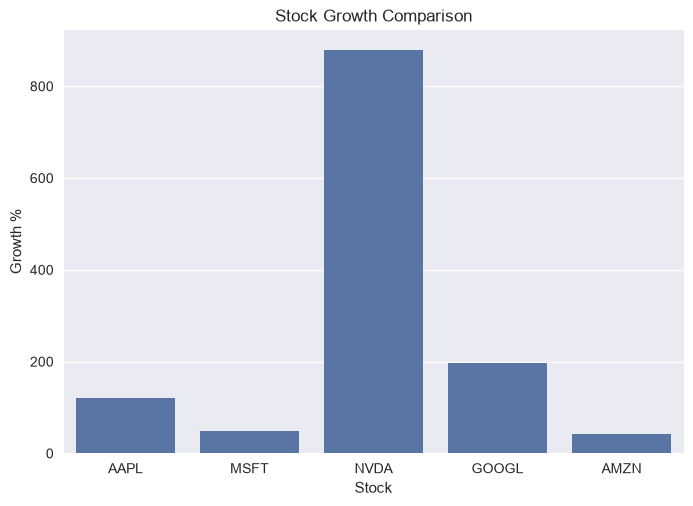

In [5]:
sns.barplot(
    data=summary_df,
    x="Stock",
    y="Growth %"
)

plt.title(
    "Stock Growth Comparison"
)

plt.show()

# Risk Analysis

Volatility shows how much the stock price moves.

Higher volatility means higher risk.

In [12]:
risk_data = []


for stock in stocks:

    prices = data[stock]["Close"]


    # convert to simple values
    prices = prices.squeeze()


    returns = prices.pct_change()


    risk = returns.std()


    risk_data.append(
        {
            "Stock": stock,
            "Risk": round(float(risk) * 100, 2)
        }
    )


risk_df = pd.DataFrame(risk_data)


risk_df

,Stock,Risk
0,AAPL,1.75
1,MSFT,1.70
2,NVDA,3.26
3,GOOGL,1.99
4,AMZN,2.25


# Risk Comparison

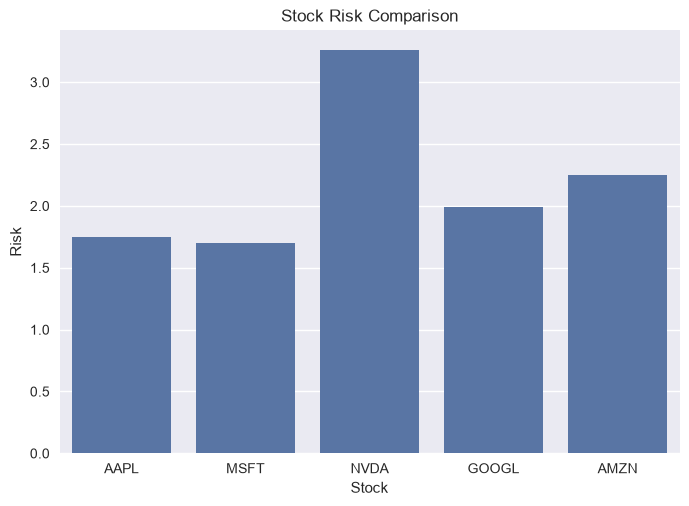

In [9]:
sns.barplot(
    data=risk_df,
    x="Stock",
    y="Risk"
)

plt.title("Stock Risk Comparison")

plt.show()

## Price Movement

We visualize stock price changes over time.

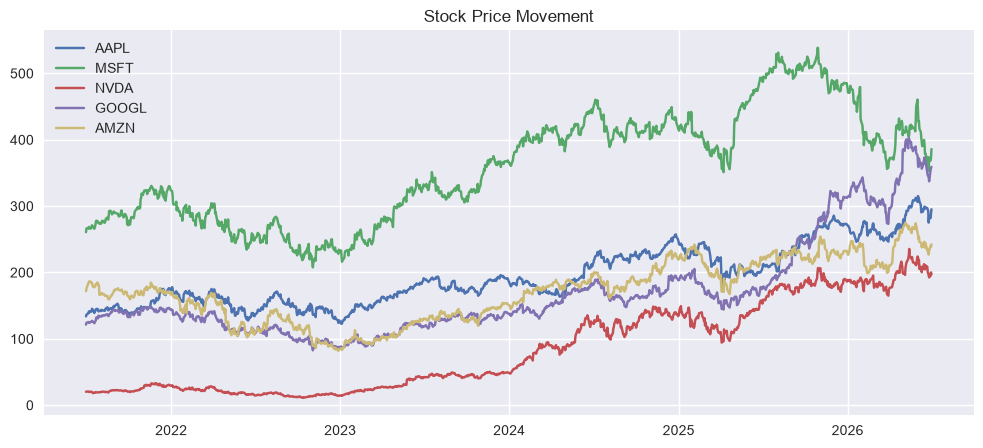

In [10]:
plt.figure(figsize=(12,5))


for stock in stocks:

    plt.plot(
        data[stock]["Close"],
        label=stock
    )


plt.legend()

plt.title(
    "Stock Price Movement"
)

plt.show()

# Final Stock Ranking

We combine growth and risk.

Higher growth + lower risk = better score.

In [11]:
final_df = summary_df.merge(
    risk_df,
    on="Stock"
)


final_df["Score"] = (
    final_df["Growth %"]
    -
    final_df["Risk"]
)


final_df = final_df.sort_values(
    "Score",
    ascending=False
)


final_df

,Stock,Growth %,Risk,Score
2,NVDA,878.93,3.26,875.67
3,GOOGL,195.92,1.99,193.93
0,AAPL,120.64,1.75,118.89
1,MSFT,48.07,1.70,46.37
4,AMZN,41.14,2.25,38.89


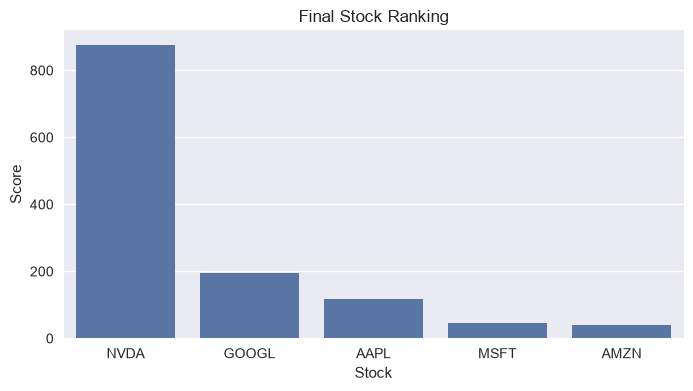

In [13]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=final_df,
    x="Stock",
    y="Score"
)

plt.title("Final Stock Ranking")

plt.show()

# Correlation Analysis

This shows how stock movements are related.

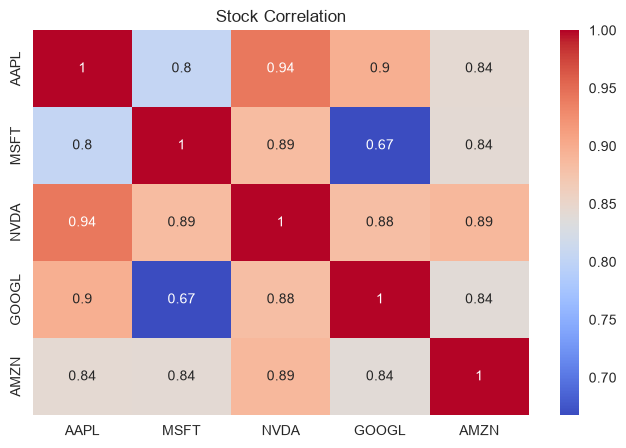

In [14]:
prices = pd.DataFrame()

for stock in stocks:
    prices[stock] = (
        data[stock]["Close"]
        .squeeze()
    )


plt.figure(figsize=(8,5))

sns.heatmap(
    prices.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Stock Correlation")

plt.show()

# Business Insights

From the analysis:

- Stocks have different growth patterns.
- High growth can also come with higher risk.
- Long-term price trends help compare companies.
- Data helps make investment decisions instead of guessing.

# Final Conclusion

This project analyzed real stock market data using Python.

We collected stock prices, cleaned the data,
calculated performance and risk, visualized trends,
and created a simple ranking system.

This project demonstrates basic financial data analysis
and introduces quantitative investing concepts.